In [23]:
# ==============================================================================
# CÉLULA 00: SETUP E DEFINIÇÃO DO DIRETÓRIO RAIZ (ROOT)
# ==============================================================================
import os
import sys

# 1. Verificação do ambiente de execução (Nuvem vs Local)
if 'google.colab' in sys.modules:
    print("☁️ Ambiente detectado: Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')

    # Insira abaixo o caminho exato onde clonou/salvou este repositório no seu Google Drive.
    caminho_projeto = '/content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub'

else:
    print("💻 Ambiente detectado: Local (Jupyter, VS Code, Spyder)")
    # Assume dinamicamente a pasta onde o notebook foi aberto como a raiz
    caminho_projeto = os.getcwd()

# 2. Configuração global do diretório de trabalho
try:
    os.chdir(caminho_projeto)
    if caminho_projeto not in sys.path:
        sys.path.append(caminho_projeto)
    print(f"✅ Diretório raiz configurado com sucesso: {os.getcwd()}")
except FileNotFoundError:
    print(f"❌ ERRO: A pasta '{caminho_projeto}' não foi encontrada.")
    print("Por favor, verifique se o caminho inserido está correto.")
    raise

☁️ Ambiente detectado: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Diretório raiz configurado com sucesso: /content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub


In [24]:
import pandas as pd
import geopandas as gpd
import joblib
import os
!pip install pyogrio -q

from src.spatial_utils import classificar_risco_operacional

In [25]:
from datetime import datetime, timedelta

# Defina o nome do cenário atual aqui (sem espaços, use underlines)
nome_cenario = "abrangente"

# Garante a existência da data base e adiciona o nome do cenário ao final
if 'data_hora_base' not in globals():
    data_hora_base = datetime.now().strftime("_%Y%m%d-%H%M")

sufixo_data = f"{data_hora_base}_{nome_cenario}"

print(sufixo_data)

_20260406-1406_abrangente


In [26]:
# ==============================================================================
# CÉLULA 01: CARREGAMENTO DO MASTER DATASET E DEFINIÇÃO DO ESCOPO
# ==============================================================================
import pandas as pd
import geopandas as gpd

# 1. Carregamento do Novo Master Dataset
file_path = "data/processed/dataset_MASTER_sem-estradas_azimute_cat.parquet"
print("📂 Carregando dataset master deduplicado...")
df_parquet = pd.read_parquet(file_path)

# Convertendo binário WKB para geometrias ativas
if isinstance(df_parquet['geometry'].iloc[0], bytes):
    df_parquet['geometry'] = gpd.GeoSeries.from_wkb(df_parquet['geometry'])

# 2. Transformar com sucesso em GeoDataFrame
df_full = gpd.GeoDataFrame(df_parquet, geometry='geometry', crs="EPSG:31983")

print(f"🌍 Base Total Carregada: {len(df_full)} segmentos viários.")

📂 Carregando dataset master deduplicado...
🌍 Base Total Carregada: 110901 segmentos viários.


In [28]:
# ==============================================================================
# CÉLULA 02: PREDIÇÃO, CLASSIFICAÇÃO PELAS MEDIANAS E EXPORTAÇÃO
# ==============================================================================

print("📥 1. Carregando modelo e threshold otimizado...")
pipeline_xgb = joblib.load(f'results/models/modelo_xgb_{nome_cenario}.pkl')
limiar_acao = joblib.load(f'results/models/threshold_{nome_cenario}.pkl')
metadados = joblib.load(f'results/models/metadados_{nome_cenario}.pkl')

features_num = metadados['features_numericas']
features_cat = metadados['features_categoricas']
medianas = metadados['medianas_treino']

print("🌍 2. Gerando probabilidades para a cidade...")
df_mapa = df_full.copy()
X_cidade = df_mapa[features_num + features_cat].copy()

for col in features_num:
    X_cidade[col] = X_cidade[col].fillna(medianas[col])

df_mapa['Prob_Queda'] = pipeline_xgb.predict_proba(X_cidade)[:, 1]

print("📏 3. Classificando Risco por Medianas Condicionais...")
# Cálculo das fronteiras baseado na densidade real das probabilidades
proba_abaixo = df_mapa[df_mapa['Prob_Queda'] < limiar_acao]['Prob_Queda']
proba_acima = df_mapa[df_mapa['Prob_Queda'] >= limiar_acao]['Prob_Queda']

m_inf = proba_abaixo.median()
m_sup = proba_acima.median()

def classificar_final(p):
    if p >= m_sup:      return '1. Crítico'
    elif p >= limiar_acao: return '2. Alto'
    elif p >= m_inf:       return '3. Moderado'
    else:               return '4. Baixo'

df_mapa['Nivel_Risco'] = df_mapa['Prob_Queda'].apply(classificar_final)

print(f"   Limites: Baixo < {m_inf:.3f} < Moderado < {limiar_acao:.3f} < Alto < {m_sup:.3f} < Crítico")
print(df_mapa['Nivel_Risco'].value_counts().sort_index())

print("\n💾 4. Exportando GeoPackage...")
if isinstance(df_mapa['geometry'].iloc[0], bytes):
    df_mapa['geometry'] = gpd.GeoSeries.from_wkb(df_mapa['geometry'])

gdf_mapa = gpd.GeoDataFrame(df_mapa, geometry='geometry', crs="EPSG:31983")
caminho_gpkg = f'results/maps/03_atlas_risco_qgis_{nome_cenario}.gpkg'
os.makedirs('results/maps', exist_ok=True)
gdf_mapa.to_file(caminho_gpkg, driver="GPKG")

print(f"✅ Sucesso! Mapa salvo em: {caminho_gpkg}")

📥 1. Carregando modelo e threshold otimizado...
🌍 2. Gerando probabilidades para a cidade...
📏 3. Classificando Risco por Medianas Condicionais...
   Limites: Baixo < 0.317 < Moderado < 0.440 < Alto < 0.569 < Crítico
Nivel_Risco
1. Crítico     25620
2. Alto        25619
3. Moderado    29831
4. Baixo       29831
Name: count, dtype: int64

💾 4. Exportando GeoPackage...
✅ Sucesso! Mapa salvo em: results/maps/03_atlas_risco_qgis_abrangente.gpkg


In [29]:
# ==============================================================================
# CÉLULA 04: EXPORTAÇÃO WEB (QGIS2WEB)
# ==============================================================================
import os
import geopandas as gpd

print("📦 Preparando arquivo otimizado para Webmapping...")

# 1. ATUALIZADO: Usamos os nomes exatos das colunas geradas pela Célula 10
colunas_web = [
    'cvc_tplogr', 'cvc_nomelg',
    'Prob_Queda',
    'Nivel_Risco',
    'geometry'
]

# 2. ATUALIZADO: Puxamos os dados do 'gdf_mapa' (e não do df_full)
gdf_webmap = gdf_mapa[colunas_web].copy()

# 3. Formatação Inteligente para o Popup (Evita duplicação do tipo de logradouro)
def limpar_endereco(row):
    tipo = str(row['cvc_tplogr']).strip()
    nome = str(row['cvc_nomelg']).strip()

    # Tratamento de nulos
    if nome in ['nan', 'None', '']: return tipo
    if tipo in ['nan', 'None', '']: return nome.title()

    # Se o nome já começar com a sigla/tipo, usamos só o nome
    if nome.lower().startswith(tipo.lower()):
        return nome.title()
    else:
        return f"{tipo} {nome}".title()

# Aplica a limpeza
gdf_webmap['endereco_busca'] = gdf_webmap.apply(limpar_endereco, axis=1)

# Formata a probabilidade para leitura humana no Popup
gdf_webmap['prob_formatada'] = (gdf_webmap['Prob_Queda'] * 100).round(1).astype(str) + "%"

# Renomeia a coluna Nivel_Risco para classe_risco para ficar limpo no QGIS
gdf_webmap.rename(columns={'Nivel_Risco': 'classe_risco'}, inplace=True)

# Mantém apenas as 4 colunas essenciais para a web
gdf_webmap = gdf_webmap[['endereco_busca', 'prob_formatada', 'classe_risco', 'geometry']]

print("✂️ Simplificando geometrias para reduzir o peso do arquivo...")
# Simplifica no formato original em metros (UTM)
gdf_webmap['geometry'] = gdf_webmap.geometry.simplify(1.0)

print("🌐 Reprojetando coordenadas para WGS84 (Padrão Web)...")
# O EPSG:4326 é pesado de gerar em bases grandes, por isso a simplificação vem antes
gdf_webmap = gdf_webmap.to_crs(epsg=4326)

# 4. Exportação
os.makedirs('results/maps', exist_ok=True)
sufixo = sufixo_data if 'sufixo_data' in globals() else ''
caminho_exportacao = f'results/maps/mapa_risco_qgis2web{sufixo}.geojson'

# Exportação ultra-rápida com o engine pyogrio
gdf_webmap.to_file(caminho_exportacao, driver='GeoJSON', engine='pyogrio')

print(f"✅ Arquivo LEVE exportado com sucesso para: {caminho_exportacao}")

📦 Preparando arquivo otimizado para Webmapping...
✂️ Simplificando geometrias para reduzir o peso do arquivo...
🌐 Reprojetando coordenadas para WGS84 (Padrão Web)...
✅ Arquivo LEVE exportado com sucesso para: results/maps/mapa_risco_qgis2web_20260406-1406_abrangente.geojson


🎨 Renderizando mapa estático de alta resolução (300 DPI)...
✅ Base encontrada na memória. Preparando plotagem...
📏 Garantindo projeção UTM (Sirgas 2000) para proporções reais...
🧮 Calculando os rótulos matemáticos da legenda...
✅ Mapa final gerado e exportado com sucesso em: results/figures/03_mapa_risco_final_sp_20260406-1406_abrangente.png


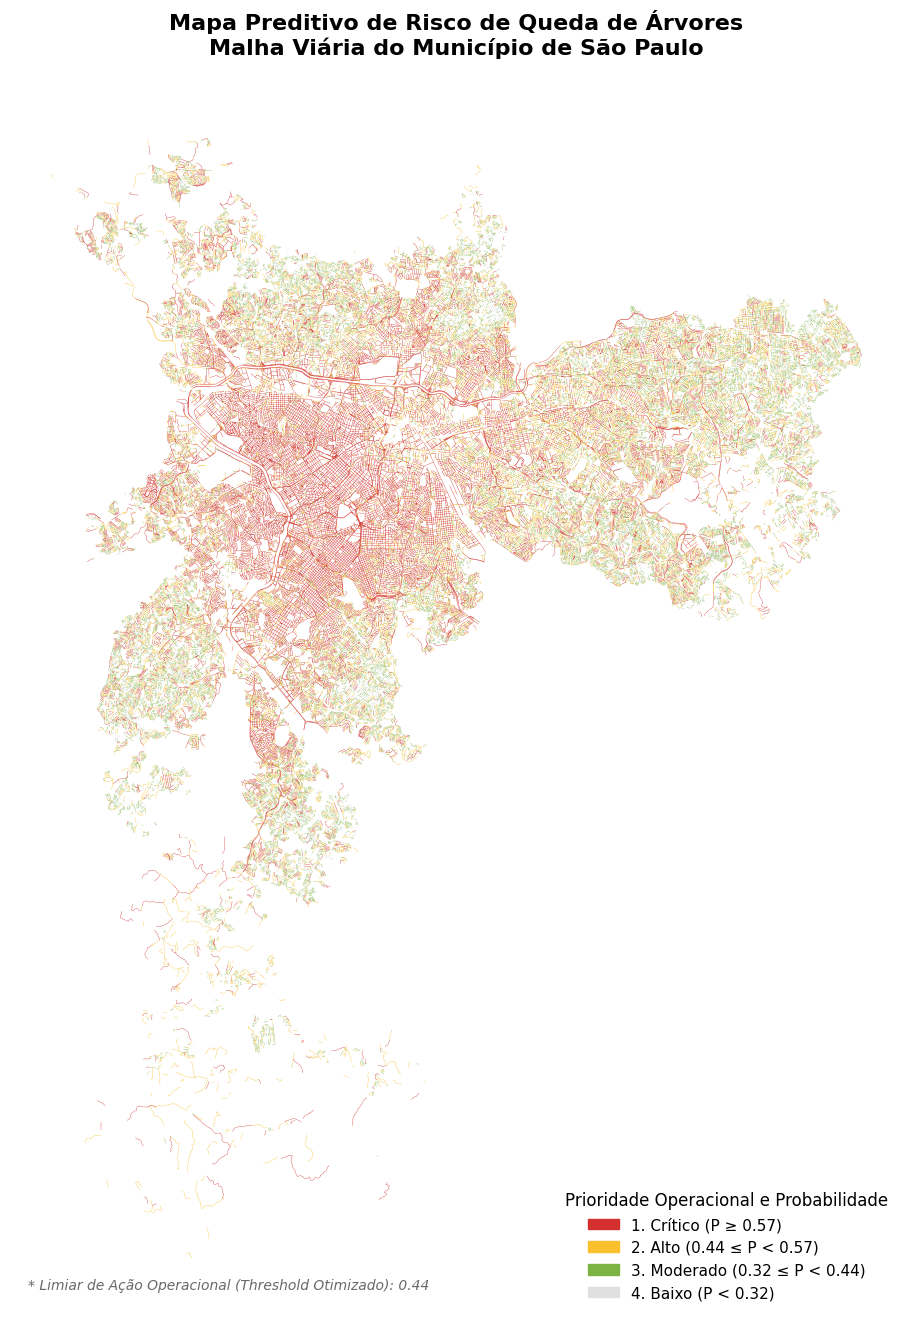

In [30]:
# ==============================================================================
# RENDERIZAÇÃO DO MAPA ESTÁTICO DE ALTA RESOLUÇÃO (PARA A DISSERTAÇÃO)
# ==============================================================================
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("🎨 Renderizando mapa estático de alta resolução (300 DPI)...")

# 1. RECUPERAÇÃO INTELIGENTE DA BASE ESPACIAL
sufixo = sufixo_data if 'sufixo_data' in globals() else f'_{nome_cenario}'
caminho_gpkg = f'results/maps/03_atlas_risco_qgis{sufixo}.gpkg'

if 'gdf_mapa' in globals():
    print("✅ Base encontrada na memória. Preparando plotagem...")
    gdf_plot = globals()['gdf_mapa'].copy()
elif os.path.exists(caminho_gpkg):
    print(f"📥 Variável não encontrada na memória. Carregando do disco: {caminho_gpkg}...")
    gdf_plot = gpd.read_file(caminho_gpkg)
else:
    raise FileNotFoundError("❌ Base de dados não encontrada. Rode a Célula 02 primeiro!")

# CORREÇÃO CARTOGRÁFICA
print("📏 Garantindo projeção UTM (Sirgas 2000) para proporções reais...")
gdf_plot = gdf_plot.to_crs("EPSG:31983")

# ---------------------------------------------------------
# 🚨 EXTRAÇÃO DOS LIMITES NUMÉRICOS PARA A LEGENDA
# ---------------------------------------------------------
print("🧮 Calculando os rótulos matemáticos da legenda...")
# Puxa o menor valor de cada grupo para criar a legenda perfeitamente atrelada aos dados
thr_plot = gdf_plot[gdf_plot['Nivel_Risco'] == '2. Alto']['Prob_Queda'].min()
msup_plot = gdf_plot[gdf_plot['Nivel_Risco'] == '1. Crítico']['Prob_Queda'].min()
minf_plot = gdf_plot[gdf_plot['Nivel_Risco'] == '3. Moderado']['Prob_Queda'].min()

# Construção dinâmica das labels
labels_legenda = {
    '1. Crítico': f'1. Crítico (P ≥ {msup_plot:.2f})',
    '2. Alto': f'2. Alto ({thr_plot:.2f} ≤ P < {msup_plot:.2f})',
    '3. Moderado': f'3. Moderado ({minf_plot:.2f} ≤ P < {thr_plot:.2f})',
    '4. Baixo': f'4. Baixo (P < {minf_plot:.2f})'
}
# ---------------------------------------------------------

# 2. PLOTAGEM DO MAPA
fig, ax = plt.subplots(figsize=(12, 16))

paleta_risco = {
    '1. Crítico': '#D32F2F',    # Vermelho Carmim
    '2. Alto': '#FBC02D',       # Amarelo Ouro
    '3. Moderado': '#7CB342',   # Verde Maçã
    '4. Baixo': '#E0E0E0'       # Cinza Neutro
}

ordem_plotagem = ['4. Baixo', '3. Moderado', '2. Alto', '1. Crítico']
linhas_plotadas = 0

for nivel in ordem_plotagem:
    subset = gdf_plot[gdf_plot['Nivel_Risco'] == nivel]
    if not subset.empty:
        espessura = 0.4 if nivel == '4. Baixo' else 0.8
        subset.plot(ax=ax, color=paleta_risco[nivel], linewidth=espessura)
        linhas_plotadas += len(subset)

# Estética Acadêmica
ax.set_axis_off()
ax.set_title('Mapa Preditivo de Risco de Queda de Árvores\nMalha Viária do Município de São Paulo',
             fontsize=16, pad=20, weight='bold')

# Legenda Dinâmica e Acadêmica (usando os dicionários criados acima)
legend_patches = [mpatches.Patch(color=paleta_risco[n], label=labels_legenda[n]) for n in ordem_plotagem[::-1]]
ax.legend(handles=legend_patches, title="Prioridade Operacional e Probabilidade",
          loc='lower right', frameon=False, fontsize=11, title_fontsize=12)

# Adicionando Nota de Rodapé com o Threshold
ax.text(0.02, 0.02, f'* Limiar de Ação Operacional (Threshold Otimizado): {thr_plot:.2f}',
        transform=ax.transAxes, fontsize=10, style='italic', color='dimgrey')

# Exportação
os.makedirs('results/figures', exist_ok=True)
caminho_mapa = f'results/figures/03_mapa_risco_final_sp{sufixo}.png'

plt.savefig(caminho_mapa, dpi=300, bbox_inches='tight', facecolor='white')

print(f"✅ Mapa final gerado e exportado com sucesso em: {caminho_mapa}")
plt.show()